# Multiple Linear Regression Lab

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl

In [3]:
df = pd.read_csv("FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
cdf = df[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_CITY","FUELCONSUMPTION_HWY","FUELCONSUMPTION_COMB","CO2EMISSIONS"]]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,196
1,2.4,4,11.2,7.7,9.6,221
2,1.5,4,6.0,5.8,5.9,136
3,3.5,6,12.7,9.1,11.1,255
4,3.5,6,12.1,8.7,10.6,244


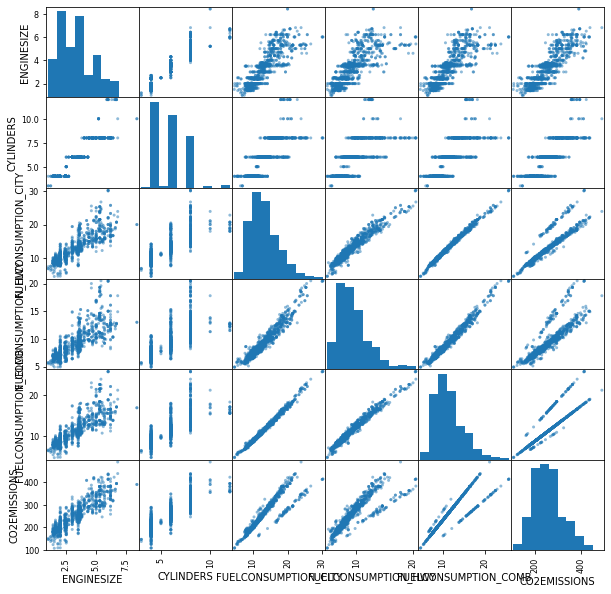

In [7]:
pd.plotting.scatter_matrix(cdf, figsize=(10,10))
plt.show()

In [14]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

In [20]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
X = np.array(train[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB"]])
y = np.array(train[["CO2EMISSIONS"]])
regr.fit(X,y)
print(regr.coef_)

[[11.5451009   7.08499788  9.70278922]]


In [23]:
from sklearn.metrics import r2_score
y_hat = regr.predict(test[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB"]])
X = np.array(test[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB"]])
y = np.array(test[["CO2EMISSIONS"]])
print(f"MSE: {np.mean((y_hat - y)**2):.2f}")
print(r2_score(y, y_hat))

MSE: 621.91
0.8316424516852712
